In [1]:
import pandas as pd

# Load behavioural + RW output
csv_path = "participant_P001_session_1_RW_trialoutcome_singlealpha.csv"
behav = pd.read_csv(csv_path)

# Keep only trial rows if there are other markers
behav = behav[behav["trial_type"] == "trial"].reset_index(drop=True)

# Extract predictors: expected value and prediction error (shape: n_trials,)
V_RW = behav["V_RW"].values        # expected value
PE_RW = behav["PE_RW"].values      # prediction error
trials = behav["trial"].values


In [2]:
import mne

epochs = mne.read_epochs("/Users/arthurhsia/Desktop/Psychology/EEG/data/derivatives/mne_preproc/sub-01/ses-01/sub-01_ses-01_task-Cannonball_MF_epochs_feedback_clean_alpha-epo.fif", preload=True)
# Make sure these epochs are already trial‑aligned with your RW CSV
print(epochs)


Reading /Users/arthurhsia/Desktop/Psychology/EEG/data/derivatives/mne_preproc/sub-01/ses-01/sub-01_ses-01_task-Cannonball_MF_epochs_feedback_clean_alpha-epo.fif ...
    Found the data of interest:
        t =    -199.22 ...     800.78 ms
        0 CTF compensation matrices available
Not setting metadata
715 matching events found
No baseline correction applied
0 projection items activated
<EpochsFIF | 715 events (all good), -0.199 – 0.801 s (baseline -0.2 – 0 s), ~95.4 MiB, data loaded,
 'loss': 261
 'reward': 454>


In [4]:
import mne
import numpy as np

# epochs: your cleaned Epochs object (time-locked to the event of interest)
epochs_alpha = epochs.copy().filter(8., 12., fir_design="firwin")


Setting up band-pass filter from 8 - 12 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 12.00 Hz
- Upper transition bandwidth: 3.00 Hz (-6 dB cutoff frequency: 13.50 Hz)
- Filter length: 423 samples (1.652 s)



/var/folders/bg/35xhpjxn5mn8n4n2k4h8pc8w0000gn/T/ipykernel_1608/3724927713.py:5: RuntimeWarning: filter_length (423) is longer than the signal (257), distortion is likely. Reduce filter length or filter a longer signal.
  epochs_alpha = epochs.copy().filter(8., 12., fir_design="firwin")


In [5]:
epochs_alpha_h = epochs_alpha.copy().apply_hilbert(envelope=False)
data_h = epochs_alpha_h.get_data()   # shape: (n_trials, n_channels, n_times), complex


In [6]:
alpha_amp = np.abs(data_h)          # instantaneous alpha amplitude
# or, for power:
alpha_power = alpha_amp ** 2


In [7]:
times = epochs_alpha.times          # time vector in seconds
tmin, tmax = 0.0, 1.0               # adapt
time_mask = (times >= tmin) & (times <= tmax)


In [8]:
posterior = ['Oz', 'P1', 'PO3', 'PO7', 'PO8', 'O1', 'O2']
posterior = [ch for ch in posterior if ch in epochs_alpha.ch_names]
idx_post = [epochs_alpha.ch_names.index(ch) for ch in posterior]


In [9]:
# (trials, channels, times) → mean over chosen times → (trials, channels)
alpha_win_ch = alpha_power[:, :, time_mask].mean(axis=2)

# mean over posterior channels → (trials,)
alpha_post = alpha_win_ch[:, idx_post].mean(axis=1)

# optional normalisation (per participant)
alpha_post_norm = alpha_post / alpha_post.max()


In [10]:
from scipy.stats import pearsonr

# V_RW: expected values per trial from behaviour-fitted RW
n = min(len(V_RW), len(alpha_post_norm))
r, p = pearsonr(V_RW[:n], alpha_post_norm[:n])
print("r(V, alpha) =", r, "p =", p)


r(V, alpha) = -0.0018398797006111067 p = 0.9608305213078477


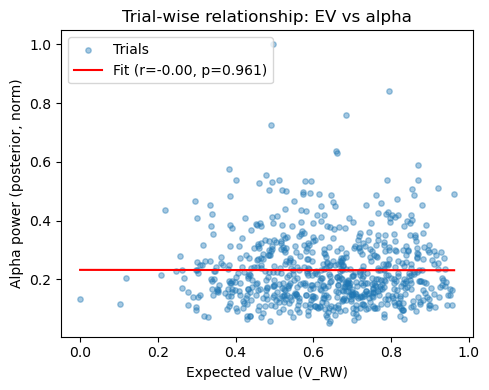

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# V_RW and alpha_post_norm must be same length and aligned
n = min(len(V_RW), len(alpha_post_norm))
x = V_RW[:n]
y = alpha_post_norm[:n]

# Fit simple linear regression y = a + b x
slope, intercept, r, p, stderr = linregress(x, y)

x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

plt.figure(figsize=(5, 4))
plt.scatter(x, y, alpha=0.4, s=15, label="Trials")
plt.plot(x_line, y_line, color="red", label=f"Fit (r={r:.2f}, p={p:.3f})")
plt.xlabel("Expected value (V_RW)")
plt.ylabel("Alpha power (posterior, norm)")
plt.title("Trial-wise relationship: EV vs alpha")
plt.legend()
plt.tight_layout()
plt.show()


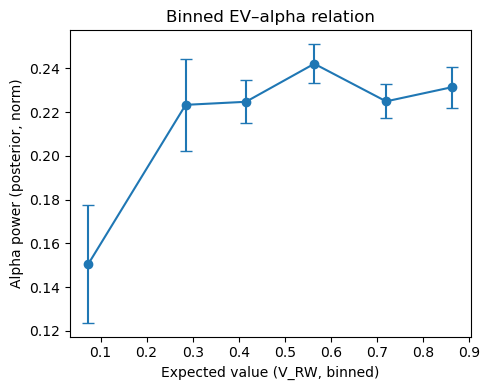

In [15]:
n_bins = 6
bins = np.linspace(x.min(), x.max(), n_bins+1)
bin_idx = np.digitize(x, bins) - 1

bin_centers = []
bin_means = []
bin_sems = []

for b in range(n_bins):
    mask = bin_idx == b
    if mask.sum() == 0:
        continue
    bin_centers.append(x[mask].mean())
    bin_means.append(y[mask].mean())
    bin_sems.append(y[mask].std(ddof=1) / np.sqrt(mask.sum()))

bin_centers = np.array(bin_centers)
bin_means   = np.array(bin_means)
bin_sems    = np.array(bin_sems)

plt.figure(figsize=(5, 4))
plt.errorbar(bin_centers, bin_means, yerr=bin_sems,
             fmt="o-", capsize=4)
plt.xlabel("Expected value (V_RW, binned)")
plt.ylabel("Alpha power (posterior, norm)")
plt.title("Binned EV–alpha relation")
plt.tight_layout()
plt.show()


In [16]:
import numpy as np
from scipy.stats import pearsonr

# make sure both arrays are same length and aligned
n = min(len(V_RW), len(alpha_post_norm))
V = V_RW[:n]
A = alpha_post_norm[:n]

r, p = pearsonr(V, A)
print("r =", r, "p =", p)


r = -0.0018398797006111067 p = 0.9608305213078477
